# Demo 1 — Federated Learning on NTU RGB+D 60 (Real Data)

This notebook trains the federated STGCN++ model on the **real NTU RGB+D 60** skeleton dataset
using Colab's T4 GPU, then exports to ONNX for use with Demo 2's `demo_onnx.py`.

**Dataset:** NTU RGB+D 60 — 56,880 skeleton sequences, 60 action classes, 17 COCO joints (HRNet 2D)  
**Split:** Cross-subject (xsub) — 40 training subjects / 16 test subjects  
**FL Setup:** 5 clients with Dirichlet non-IID partitioning (α=0.5)  
**Strategy:** Warm-start pretraining (3 epochs centralized) → 5 rounds of FedAvg + BN calibration

**Highlights:**
- Centralized warm-start baseline for fast convergence
- Live FL training dashboard with per-client metrics
- Rich 6-panel visualization of the entire FL process
- Confusion matrix analysis of the final model

**Runtime → Change runtime type → T4 GPU** before running.

## 1. Setup & Install Dependencies

In [ ]:
# Install dependencies (no Flower needed — we use a manual FL loop)
!pip install -q onnx onnxsim onnxruntime scikit-learn

import torch
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
assert torch.cuda.is_available(), "No GPU! Go to Runtime → Change runtime type → T4 GPU"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 75.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 75.6 MB/s eta 0:00:00:00:0100:01
PyTorch 2.10.0+cu128  |  CUDA: True
GPU: Tesla T4


## 2. Download NTU RGB+D 60 Skeleton Data

Pre-extracted 2D HRNet keypoints from the pyskl project (~200 MB).  
Contains 56,880 skeleton sequences with 17 COCO joints.

In [2]:
import os

data_dir = 'data/nturgbd'
pkl_path = f'{data_dir}/ntu60_hrnet.pkl'

if not os.path.exists(pkl_path):
    os.makedirs(data_dir, exist_ok=True)
    !wget -q --show-progress -O {pkl_path} \
        https://download.openmmlab.com/mmaction/pyskl/data/nturgbd/ntu60_hrnet.pkl
    print(f'Downloaded: {pkl_path}')
else:
    print(f'Already exists: {pkl_path}')

print(f'Size: {os.path.getsize(pkl_path) / 1024**2:.1f} MB')

data/nturgbd/ntu60_ 100%[===================>] 672.72M  16.1MB/s    in 45s     
Downloaded: data/nturgbd/ntu60_hrnet.pkl
Size: 672.7 MB


## 3. Explore & Preprocess the Dataset

In [3]:
import pickle
import numpy as np
from collections import Counter, defaultdict

# Load the pkl
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

split_info = data['split']
annotations = data['annotations']

print(f'Total annotations: {len(annotations)}')
print(f'Available splits: {list(split_info.keys())}')

# Count split sizes
for split_name, frame_dirs in split_info.items():
    print(f'  {split_name}: {len(frame_dirs)} samples')

# Examine one sample
sample = annotations[0]
print(f'\nSample keys: {list(sample.keys())}')
print(f'  frame_dir: {sample["frame_dir"]}')
print(f'  label: {sample["label"]}')
print(f'  total_frames: {sample["total_frames"]}')
print(f'  keypoint shape: {sample["keypoint"].shape}')       # (M, T, V, 2)
print(f'  keypoint_score shape: {sample["keypoint_score"].shape}')  # (M, T, V)
if 'img_shape' in sample:
    print(f'  img_shape: {sample["img_shape"]}')

Total annotations: 56578
Available splits: ['xsub_train', 'xsub_val', 'xview_train', 'xview_val']
  xsub_train: 40091 samples
  xsub_val: 16487 samples
  xview_train: 37646 samples
  xview_val: 18932 samples

Sample keys: ['frame_dir', 'label', 'img_shape', 'original_shape', 'total_frames', 'keypoint', 'keypoint_score']
  frame_dir: S001C001P001R001A001
  label: 0
  total_frames: 103
  keypoint shape: (1, 103, 17, 2)
  keypoint_score shape: (1, 103, 17)
  img_shape: (1080, 1920)


In [4]:
# Label distribution
label_counts = Counter(ann['label'] for ann in annotations)
print(f'Number of classes: {len(label_counts)}')
print(f'Samples per class: min={min(label_counts.values())}, max={max(label_counts.values())}, '
      f'mean={np.mean(list(label_counts.values())):.0f}')

# NTU-60 action labels
NTU60_LABELS = [
    "drink water", "eat meal/snack", "brushing teeth", "brushing hair", "drop",
    "pickup", "throw", "sitting down", "standing up", "clapping",
    "reading", "writing", "tear up paper", "wear jacket", "take off jacket",
    "wear a shoe", "take off a shoe", "wear on glasses", "take off glasses",
    "put on a hat/cap", "take off a hat/cap", "cheer up", "hand waving",
    "kicking something", "reach into pocket", "hopping", "jump up",
    "make a phone call", "playing with phone/tablet", "typing on a keyboard",
    "pointing to something", "taking a selfie", "check time (from watch)",
    "rub two hands together", "nod head/bow", "shake head", "wipe face",
    "salute", "put the palms together", "cross hands in front",
    "sneeze/cough", "staggering", "falling", "touch head (headache)",
    "touch chest (heart pain)", "touch back (backache)", "touch neck (neckache)",
    "nausea or vomiting", "use a fan/feeling warm",
    "punching/slapping other person", "kicking other person",
    "pushing other person", "pat on back of other person",
    "point finger at other person", "hugging other person",
    "giving something to other person", "touch other person's pocket",
    "handshaking", "walking towards each other", "walking apart from each other",
]
NUM_CLASSES = len(NTU60_LABELS)
print(f'\n60 action classes loaded')
for i in range(0, 60, 10):
    print(f'  [{i:2d}-{i+9:2d}] {", ".join(NTU60_LABELS[i:i+10])}')

Number of classes: 60
Samples per class: min=906, max=948, mean=943

60 action classes loaded
  [ 0- 9] drink water, eat meal/snack, brushing teeth, brushing hair, drop, pickup, throw, sitting down, standing up, clapping
  [10-19] reading, writing, tear up paper, wear jacket, take off jacket, wear a shoe, take off a shoe, wear on glasses, take off glasses, put on a hat/cap
  [20-29] take off a hat/cap, cheer up, hand waving, kicking something, reach into pocket, hopping, jump up, make a phone call, playing with phone/tablet, typing on a keyboard
  [30-39] pointing to something, taking a selfie, check time (from watch), rub two hands together, nod head/bow, shake head, wipe face, salute, put the palms together, cross hands in front
  [40-49] sneeze/cough, staggering, falling, touch head (headache), touch chest (heart pain), touch back (backache), touch neck (neckache), nausea or vomiting, use a fan/feeling warm, punching/slapping other person
  [50-59] kicking other person, pushing othe

## 4. Preprocessing Pipeline

Replicates pyskl's standard GCN preprocessing:
1. **PreNormalize2D** — normalize x,y to [-1,1] range, concat keypoint_score as 3rd channel
2. **UniformSample** — sample exactly 100 frames (pad if shorter, subsample if longer)
3. **FormatGCNInput** — pad/trim to exactly 2 persons

Output shape per sample: `(M=2, T=100, V=17, C=3)`

In [5]:
def prenormalize_2d(keypoint, keypoint_score, img_shape=(1080, 1920), threshold=0.01):
    """Normalize 2D keypoints to [-1, 1] and concat score as 3rd channel."""
    kp = keypoint.astype(np.float32).copy()
    score = keypoint_score.astype(np.float32)

    # Concat score → (M, T, V, 3)
    kp = np.concatenate([kp, score[..., None]], axis=-1)

    # Mask low-confidence
    mask_out = kp[..., 2] <= threshold

    # Normalize to [-1, 1] using image dimensions
    h, w = img_shape
    kp[..., 0] = (kp[..., 0] - w / 2) / (w / 2)  # x
    kp[..., 1] = (kp[..., 1] - h / 2) / (h / 2)  # y

    # Zero out low-confidence joints
    kp[..., 0][mask_out] = 0
    kp[..., 1][mask_out] = 0

    return kp  # (M, T, V, 3)


def uniform_sample(keypoint, clip_len=100):
    """Sample exactly clip_len frames uniformly."""
    M, T, V, C = keypoint.shape
    if T == clip_len:
        return keypoint
    elif T < clip_len:
        # Repeat/tile to fill
        inds = np.arange(clip_len) % T
    else:
        # Uniform subsample
        inds = np.linspace(0, T - 1, clip_len, dtype=int)
    return keypoint[:, inds]  # (M, clip_len, V, C)


def format_gcn_input(keypoint, num_person=2):
    """Pad or trim to exactly num_person persons."""
    M, T, V, C = keypoint.shape
    if M < num_person:
        pad = np.zeros((num_person - M, T, V, C), dtype=keypoint.dtype)
        keypoint = np.concatenate([keypoint, pad], axis=0)
    elif M > num_person:
        keypoint = keypoint[:num_person]
    return keypoint  # (num_person, T, V, C)


def preprocess_sample(ann, clip_len=100, num_person=2):
    """Full preprocessing pipeline for one annotation."""
    img_shape = ann.get('img_shape', (1080, 1920))
    kp = prenormalize_2d(ann['keypoint'], ann['keypoint_score'], img_shape)
    kp = uniform_sample(kp, clip_len)
    kp = format_gcn_input(kp, num_person)
    return kp  # (num_person, clip_len, V, 3)


# Test on one sample
test_out = preprocess_sample(annotations[0])
print(f'Preprocessed shape: {test_out.shape}')  # (2, 100, 17, 3)
print(f'Value range x: [{test_out[...,0].min():.3f}, {test_out[...,0].max():.3f}]')
print(f'Value range y: [{test_out[...,1].min():.3f}, {test_out[...,1].max():.3f}]')
print(f'Score range:   [{test_out[...,2].min():.3f}, {test_out[...,2].max():.3f}]')

Preprocessed shape: (2, 100, 17, 3)
Value range x: [0.000, 0.151]
Value range y: [-0.420, 0.309]
Score range:   [0.000, 0.997]


## 5. Build Federated Client Data Splits

1. Use **xsub** (cross-subject) train/val split from NTU-60
2. Partition training data across 5 clients using **Dirichlet(α=0.5)** for non-IID
3. Preprocess all samples to `(2, 100, 17, 3)` tensors

In [6]:
import time

# Build lookup: frame_dir → annotation
ann_lookup = {ann['frame_dir']: ann for ann in annotations}

# Get train/test splits
train_dirs = set(split_info['xsub_train'])
test_dirs = set(split_info['xsub_val'])

print(f'xsub_train: {len(train_dirs)} samples')
print(f'xsub_val:   {len(test_dirs)} samples')

# Preprocess all training data
print('\nPreprocessing training data...')
t0 = time.time()

train_x, train_y = [], []
for ann in annotations:
    if ann['frame_dir'] in train_dirs:
        x = preprocess_sample(ann)
        train_x.append(x)
        train_y.append(ann['label'])

train_x = np.stack(train_x).astype(np.float32)
train_y = np.array(train_y, dtype=np.int64)
print(f'  Train: x={train_x.shape}, y={train_y.shape} ({time.time()-t0:.1f}s)')

# Preprocess test data
print('Preprocessing test data...')
t0 = time.time()

test_x, test_y = [], []
for ann in annotations:
    if ann['frame_dir'] in test_dirs:
        x = preprocess_sample(ann)
        test_x.append(x)
        test_y.append(ann['label'])

test_x = np.stack(test_x).astype(np.float32)
test_y = np.array(test_y, dtype=np.int64)
print(f'  Test:  x={test_x.shape}, y={test_y.shape} ({time.time()-t0:.1f}s)')

# Verify shapes
assert train_x.shape[1:] == (2, 100, 17, 3), f'Bad train shape: {train_x.shape}'
assert test_x.shape[1:] == (2, 100, 17, 3), f'Bad test shape: {test_x.shape}'
print('\nShapes verified ✓')

xsub_train: 40091 samples
xsub_val:   16487 samples

Preprocessing training data...
  Train: x=(40091, 2, 100, 17, 3), y=(40091,) (7.0s)
Preprocessing test data...
  Test:  x=(16487, 2, 100, 17, 3), y=(16487,) (2.2s)

Shapes verified ✓


In [7]:
# Dirichlet non-IID split across 5 clients
NUM_CLIENTS = 5
ALPHA = 0.5  # lower = more non-IID

rng = np.random.RandomState(42)

label_indices = defaultdict(list)
for i, label in enumerate(train_y):
    label_indices[int(label)].append(i)

client_indices = {i: [] for i in range(NUM_CLIENTS)}
for cls in range(NUM_CLASSES):
    idxs = np.array(label_indices[cls])
    rng.shuffle(idxs)
    proportions = rng.dirichlet([ALPHA] * NUM_CLIENTS)
    proportions = np.cumsum(proportions) / proportions.sum()
    splits = np.split(idxs, (proportions[:-1] * len(idxs)).astype(int))
    for cid, chunk in enumerate(splits):
        client_indices[cid].extend(chunk.tolist())

print(f'Dirichlet split (α={ALPHA}):')
for cid in range(NUM_CLIENTS):
    ci = client_indices[cid]
    labels = train_y[ci]
    n_classes = len(set(labels))
    print(f'  Client {cid}: {len(ci):5d} samples, {n_classes} classes represented')

# Save client data as npz files
import os
fed_dir = 'fed_data'
os.makedirs(fed_dir, exist_ok=True)

for cid in range(NUM_CLIENTS):
    ci = np.array(client_indices[cid], dtype=int)
    np.savez_compressed(f'{fed_dir}/client_{cid}.npz', x=train_x[ci], y=train_y[ci])

np.savez_compressed(f'{fed_dir}/test.npz', x=test_x, y=test_y)
print(f'\nData saved to {fed_dir}/')

Dirichlet split (α=0.5):
  Client 0:  8470 samples, 58 classes represented
  Client 1:  6956 samples, 60 classes represented
  Client 2:  7497 samples, 56 classes represented
  Client 3:  7594 samples, 60 classes represented
  Client 4:  9574 samples, 60 classes represented

Data saved to fed_data/


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import os
matplotlib.rcParams.update({'font.size': 10})
os.makedirs('outputs', exist_ok=True)

# Build client × class distribution matrix
dist_matrix = np.zeros((NUM_CLIENTS, NUM_CLASSES), dtype=int)
for cid in range(NUM_CLIENTS):
    ci = client_indices[cid]
    for idx in ci:
        dist_matrix[cid, int(train_y[idx])] += 1

fig, axes = plt.subplots(2, 1, figsize=(18, 8), gridspec_kw={'height_ratios': [3, 1]})

# Heatmap: clients × classes
im = axes[0].imshow(dist_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[0].set_xlabel('Action Class')
axes[0].set_ylabel('Client')
axes[0].set_yticks(range(NUM_CLIENTS))
axes[0].set_yticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
axes[0].set_xticks(range(0, NUM_CLASSES, 5))
axes[0].set_title(f'Non-IID Data Distribution — Dirichlet(α={ALPHA}), {NUM_CLIENTS} Clients')
plt.colorbar(im, ax=axes[0], label='# Samples')

# Bar chart: per-client total samples
client_totals = dist_matrix.sum(axis=1)
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLIENTS))
bars = axes[1].bar(range(NUM_CLIENTS), client_totals, color=colors, edgecolor='k', linewidth=0.5)
for bar, total in zip(bars, client_totals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{total}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Client')
axes[1].set_ylabel('Total Samples')
axes[1].set_xticks(range(NUM_CLIENTS))
axes[1].set_xticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
axes[1].set_title('Samples per Client')

plt.tight_layout()
plt.savefig('outputs/data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print per-client class coverage
print('\nPer-client class coverage:')
for cid in range(NUM_CLIENTS):
    non_zero = (dist_matrix[cid] > 0).sum()
    top3 = np.argsort(dist_matrix[cid])[-3:][::-1]
    top3_str = ', '.join(f'{NTU60_LABELS[c]} ({dist_matrix[cid,c]})' for c in top3)
    print(f'  Client {cid}: {non_zero}/{NUM_CLASSES} classes | Top-3: {top3_str}')

## 6a. Model Definition (STGCN++)

Same lightweight STGCN++ architecture (443K params), now with **60 output classes** for NTU-60.  
The model will first be pre-trained centrally (Section 6b), then fine-tuned via federated learning (Section 7).

In [8]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

COCO_INWARD = [
    (15, 13), (13, 11), (16, 14), (14, 12),
    (11, 5), (12, 6), (9, 7), (7, 5), (10, 8), (8, 6),
    (5, 0), (6, 0), (1, 0), (3, 1), (2, 0), (4, 2),
]
COCO_NUM_JOINTS = 17
COCO_CENTER = 0

def _build_adjacency(num_node, edges, center):
    def _normalize(mx):
        d = mx.sum(axis=0); d[d == 0] = 1; return mx / d
    I = np.eye(num_node, dtype=np.float32)
    inward = np.zeros((num_node, num_node), dtype=np.float32)
    outward = np.zeros((num_node, num_node), dtype=np.float32)
    hop = np.full(num_node, 1e9, dtype=int); hop[center] = 0
    adj = {i: [] for i in range(num_node)}
    for u, v in edges: adj[u].append(v); adj[v].append(u)
    queue = [center]
    while queue:
        cur = queue.pop(0)
        for nb in adj[cur]:
            if hop[nb] > hop[cur] + 1: hop[nb] = hop[cur] + 1; queue.append(nb)
    for u, v in edges:
        if hop[u] < hop[v]: inward[v, u] = 1
        else: outward[u, v] = 1
    return np.stack([_normalize(I), _normalize(inward), _normalize(outward)])

def get_coco_adjacency():
    return _build_adjacency(COCO_NUM_JOINTS, COCO_INWARD, COCO_CENTER)


class MsTCN(nn.Module):
    def __init__(self, in_ch, out_ch, dilations=(1, 2, 3, 4), stride=1, dropout=0.0):
        super().__init__()
        mid = out_ch // (len(dilations) + 2)
        rem = out_ch - mid * (len(dilations) + 2)
        self.branches = nn.ModuleList()
        for d in dilations:
            self.branches.append(nn.Sequential(
                nn.Conv2d(in_ch, mid, 1), nn.BatchNorm2d(mid), nn.ReLU(True),
                nn.Conv2d(mid, mid, (3,1), stride=(stride,1), padding=(d,0), dilation=(d,1)),
                nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch, mid, 1), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.MaxPool2d((3,1), stride=(stride,1), padding=(1,0)), nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch, mid + rem, 1), nn.BatchNorm2d(mid + rem)))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        outs = [br(x) for br in self.branches]
        mt = min(o.size(2) for o in outs)
        return self.drop(torch.cat([o[:,:,:mt,:] for o in outs], dim=1))


class UnitGCN(nn.Module):
    def __init__(self, in_ch, out_ch, A, adaptive=True):
        super().__init__()
        K = A.size(0); self.K = K
        self.register_buffer('A', A)
        self.conv = nn.ModuleList([nn.Conv2d(in_ch, out_ch, 1) for _ in range(K)])
        self.PA = nn.Parameter(A.clone()) if adaptive else None
        self.bn = nn.BatchNorm2d(out_ch)
        self.res = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch)) if in_ch != out_ch else nn.Identity()
        for m in self.conv:
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x):
        adj = self.A + self.PA if self.PA is not None else self.A
        out = sum(torch.einsum('nctv,vw->nctw', self.conv[k](x), adj[k]) for k in range(self.K))
        return F.relu(self.bn(out) + self.res(x), inplace=True)


class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, A, stride=1, dropout=0.0):
        super().__init__()
        self.gcn = UnitGCN(in_ch, out_ch, A)
        self.tcn = MsTCN(out_ch, out_ch, stride=stride, dropout=dropout)
        self.residual = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch),
            nn.AvgPool2d((stride,1)) if stride > 1 else nn.Identity()
        ) if in_ch != out_ch or stride != 1 else nn.Identity()
    def forward(self, x):
        return F.relu(self.tcn(self.gcn(x)) + self.residual(x), inplace=True)


class STGCN(nn.Module):
    def __init__(self, num_classes=60, in_channels=3, base_channels=64,
                 num_stages=6, inflate_stages=None, down_stages=None,
                 num_person=2, dropout=0.0):
        super().__init__()
        if inflate_stages is None: inflate_stages = [3, 5]
        if down_stages is None: down_stages = [3, 5]
        self.num_person = num_person
        A = torch.tensor(get_coco_adjacency(), dtype=torch.float32)
        self.data_bn = nn.BatchNorm1d(in_channels * COCO_NUM_JOINTS)
        channels = [base_channels]
        for i in range(1, num_stages):
            channels.append(channels[-1] * 2 if i in inflate_stages else channels[-1])
        self.blocks = nn.ModuleList()
        c_in = in_channels
        for i in range(num_stages):
            self.blocks.append(STGCNBlock(c_in, channels[i], A,
                               stride=2 if i in down_stages else 1, dropout=dropout))
            c_in = channels[i]
        self.out_channels = channels[-1]
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(self.out_channels, num_classes)
        nn.init.normal_(self.fc.weight, 0, math.sqrt(2.0 / num_classes))
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        N, M, T, V, C = x.shape
        x = x.permute(0,1,4,2,3).contiguous().view(N*M, C, T, V)
        x = x.permute(0,1,3,2).contiguous().view(N*M, C*V, T)
        x = self.data_bn(x)
        x = x.view(N*M, C, V, T).permute(0,1,3,2).contiguous()
        for block in self.blocks:
            x = block(x)
        x = self.pool(x).view(N, M, self.out_channels).mean(dim=1)
        return self.fc(self.drop(x))

def build_model(num_classes=60, in_channels=3, **kw):
    return STGCN(num_classes=num_classes, in_channels=in_channels, **kw)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick check
_m = build_model(num_classes=60, dropout=0.3)
print(f'STGCN++ params: {count_parameters(_m):,}')
_d = torch.randn(2, 2, 100, 17, 3)
print(f'Output shape: {_m(_d).shape}')  # (2, 60)
del _m, _d

STGCN++ params: 456,072
Output shape: torch.Size([2, 60])


## 6b. Centralized Warm-Start (Pretrained Baseline)

Train the model for **3 epochs** on all training data (centralized) as a warm-start.  
This acts as a "pretrained baseline" that FL then fine-tunes — a common real-world FL strategy.

This gives the model decent initial features so that the 5-round FL process can
focus on adapting to non-IID client distributions rather than learning from scratch.

In [10]:
import time
import os
from torch.utils.data import DataLoader, TensorDataset

os.makedirs('outputs', exist_ok=True)

WARMUP_EPOCHS = 3
BATCH_SIZE = 64
DEVICE = 'cuda'

model_kwargs = dict(base_channels=64, num_stages=6, num_person=2, dropout=0.3)

# Build and train centralized model
warmup_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
warmup_model.to(DEVICE)
print(f'Model: {count_parameters(warmup_model):,} params')

# Use all training data
warmup_loader = DataLoader(
    TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader_warmup = DataLoader(
    TensorDataset(torch.from_numpy(test_x), torch.from_numpy(test_y)),
    batch_size=128)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(warmup_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

print(f'\n{"="*50}')
print(f'Centralized Warm-Start: {WARMUP_EPOCHS} epochs')
print(f'{"="*50}')

warmup_history = []
t0 = time.time()

for epoch in range(1, WARMUP_EPOCHS + 1):
    warmup_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for xb, yb in warmup_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = warmup_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    train_acc = correct / total
    train_loss = running_loss / total

    # Test
    warmup_model.eval()
    t_correct, t_total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader_warmup:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = warmup_model(xb).argmax(1)
            t_correct += (preds == yb).sum().item()
            t_total += yb.size(0)
    test_acc = t_correct / t_total

    warmup_history.append({'epoch': epoch, 'train_acc': train_acc, 'test_acc': test_acc, 'loss': train_loss})
    print(f'  Epoch {epoch}/{WARMUP_EPOCHS}  loss={train_loss:.4f}  train={train_acc:.4f}  test={test_acc:.4f}')

elapsed = time.time() - t0
print(f'\nWarm-start done in {elapsed:.0f}s — Test accuracy: {test_acc:.4f}')

# Save warm-start checkpoint
warmup_sd = {k: v.cpu() for k, v in warmup_model.state_dict().items()}
torch.save(warmup_sd, 'outputs/warmstart_ntu60.pt')
print(f'Saved: outputs/warmstart_ntu60.pt')
del warmup_model
torch.cuda.empty_cache()

Model: 456,072 params

Centralized Warm-Start: 3 epochs
  Epoch 1/3  loss=3.5676  train=0.0925  test=0.1653
  Epoch 2/3  loss=2.4791  train=0.2688  test=0.4042
  Epoch 3/3  loss=1.7096  train=0.4578  test=0.5055

Warm-start done in 1108s — Test accuracy: 0.5055
Saved: outputs/warmstart_ntu60.pt


## 7. Federated Training (FedAvg + BN Calibration)

- **5 rounds**, 5 clients, 1 epoch per round
- **Warm-start** from centralized pretrained baseline
- FedAvg aggregation (all weights including BN)
- BN calibration after each round (recompute running stats from pooled data)
- Per-round per-client accuracy tracking for visualization

In [11]:
import copy
import json
from collections import OrderedDict
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from IPython.display import display, HTML, clear_output

# ── Config ──
NUM_ROUNDS = 5
EPOCHS_PER_ROUND = 1
BATCH_SIZE = 64
LR = 0.01
DEVICE = 'cuda'

# Build global model and load warm-start weights
global_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
warmstart_path = 'outputs/warmstart_ntu60.pt'
if os.path.exists(warmstart_path):
    global_model.load_state_dict(torch.load(warmstart_path, map_location='cpu'))
    print(f'✓ Loaded warm-start weights from {warmstart_path}')
else:
    print('⚠ No warm-start checkpoint found — training from scratch')

print(f'Model: {count_parameters(global_model):,} params')
print(f'Device: {DEVICE}, Rounds: {NUM_ROUNDS}, Clients: {NUM_CLIENTS}')

# Load client data
fed_dir = Path('fed_data')
client_loaders = []
all_train_x_parts, all_train_y_parts = [], []

for cid in range(NUM_CLIENTS):
    d = np.load(fed_dir / f'client_{cid}.npz')
    xc, yc = d['x'].astype(np.float32), d['y'].astype(np.int64)
    all_train_x_parts.append(xc)
    all_train_y_parts.append(yc)
    ds = TensorDataset(torch.from_numpy(xc), torch.from_numpy(yc))
    client_loaders.append(DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False))

# Combined loader for BN calibration
calib_x = torch.from_numpy(np.concatenate(all_train_x_parts))
calib_y = torch.from_numpy(np.concatenate(all_train_y_parts))
calib_loader = DataLoader(TensorDataset(calib_x, calib_y), batch_size=128, shuffle=True)

# Test loader
test_d = np.load(fed_dir / 'test.npz')
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(test_d['x'].astype(np.float32)),
                  torch.from_numpy(test_d['y'].astype(np.int64))),
    batch_size=128)

def calibrate_bn(model, loader, device, max_batches=30):
    """Reset and recompute BN running stats."""
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.reset_running_stats()
            m.momentum = None
    model.train()
    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= max_batches: break
            model(xb.to(device))

def make_dashboard_html(history, client_acc_matrix, round_times, NUM_CLIENTS, NUM_ROUNDS):
    """Build a rich HTML dashboard for live updates."""
    rnd = len(history)

    # Header
    html = '<div style="font-family:monospace; background:#1e1e1e; color:#d4d4d4; padding:12px; border-radius:8px; margin:4px 0;">'
    html += f'<h3 style="color:#569cd6; margin:0 0 8px 0;">🔄 Federated Learning — Round {rnd}/{NUM_ROUNDS}</h3>'

    # Progress bar
    pct = rnd / NUM_ROUNDS * 100
    html += f'<div style="background:#333; border-radius:4px; height:20px; margin-bottom:10px;">'
    html += f'<div style="background:linear-gradient(90deg,#4ec9b0,#569cd6); width:{pct}%; height:100%; border-radius:4px; '
    html += f'text-align:center; color:white; font-size:12px; line-height:20px;">{pct:.0f}%</div></div>'

    # Stats row
    h = history[-1]
    html += '<table style="width:100%; margin-bottom:8px;">'
    html += '<tr>'
    for label, val, color in [
        ('Test Acc', f'{h["test_acc"]:.4f}', '#4ec9b0'),
        ('Mean Train', f'{h["mean_client_acc"]:.4f}', '#569cd6'),
        ('Worst Client', f'{h["worst_client_acc"]:.4f}', '#ce9178'),
        ('Best Client', f'{h["best_client_acc"]:.4f}', '#b5cea8'),
        ('LR', f'{h["lr"]:.4f}', '#d4d4d4'),
        ('Round Time', f'{round_times[-1]:.1f}s', '#d4d4d4'),
    ]:
        html += f'<td style="text-align:center; padding:4px;">'
        html += f'<div style="color:#888; font-size:10px;">{label}</div>'
        html += f'<div style="color:{color}; font-size:16px; font-weight:bold;">{val}</div></td>'
    html += '</tr></table>'

    # Per-client accuracy table
    html += '<table style="width:100%; border-collapse:collapse; font-size:12px;">'
    html += '<tr style="background:#2d2d2d;"><th style="padding:4px; text-align:left;">Round</th>'
    for cid in range(NUM_CLIENTS):
        html += f'<th style="padding:4px;">Client {cid}</th>'
    html += '<th style="padding:4px;">Test</th></tr>'

    for r_idx, h in enumerate(history):
        bg = '#252525' if r_idx % 2 == 0 else '#2d2d2d'
        html += f'<tr style="background:{bg};"><td style="padding:3px 6px; font-weight:bold;">R{h["round"]}</td>'
        for cid in range(NUM_CLIENTS):
            acc = client_acc_matrix[r_idx][cid]
            # Color: red < 0.3, yellow 0.3-0.6, green > 0.6
            if acc < 0.3: c = '#f44747'
            elif acc < 0.6: c = '#dcdcaa'
            else: c = '#4ec9b0'
            html += f'<td style="padding:3px; text-align:center; color:{c};">{acc:.3f}</td>'
        html += f'<td style="padding:3px; text-align:center; color:#569cd6; font-weight:bold;">{h["test_acc"]:.3f}</td>'
        html += '</tr>'
    html += '</table></div>'
    return html

# ── Training loop ──
device = torch.device(DEVICE)
criterion = nn.CrossEntropyLoss()
history = []
client_acc_matrix = []   # [round][client] = accuracy
round_times = []
dashboard_handle = display(HTML(''), display_id=True)

print(f'\n{"="*60}')
print(f'Starting Federated Training on NTU-60 (warm-start)')
print(f'{"="*60}')
t0_total = time.time()

for rnd in range(1, NUM_ROUNDS + 1):
    t0_round = time.time()
    lr = LR
    if rnd > 25: lr = LR * 0.01
    elif rnd > 15: lr = LR * 0.1

    global_sd = copy.deepcopy(global_model.state_dict())
    client_weights, client_accs, client_losses = [], [], []

    for cid in range(NUM_CLIENTS):
        local_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
        local_model.load_state_dict(global_sd)
        local_model.to(device).train()

        optimizer = torch.optim.SGD(local_model.parameters(), lr=lr,
                                     momentum=0.9, weight_decay=5e-4)
        correct, total, running_loss = 0, 0, 0.0
        for _ in range(EPOCHS_PER_ROUND):
            for xb, yb in client_loaders[cid]:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = local_model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                correct += (logits.argmax(1) == yb).sum().item()
                total += yb.size(0)
                running_loss += loss.item() * yb.size(0)

        client_accs.append(correct / max(total, 1))
        client_losses.append(running_loss / max(total, 1))
        client_weights.append((total, {k: v.cpu() for k, v in local_model.state_dict().items()}))

    # FedAvg aggregation
    all_keys = list(global_sd.keys())
    total_samples = sum(n for n, _ in client_weights)
    new_sd = OrderedDict()
    for k in all_keys:
        new_sd[k] = sum(n * sd[k].float() for n, sd in client_weights) / total_samples
    gsd = global_model.state_dict()
    for k in all_keys:
        gsd[k] = new_sd[k].to(gsd[k].dtype)
    global_model.load_state_dict(gsd)

    # BN calibration
    global_model.to(device)
    calibrate_bn(global_model, calib_loader, device)

    # Test evaluation
    global_model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = global_model(xb)
            test_correct += (logits.argmax(1) == yb).sum().item()
            test_total += yb.size(0)
    test_acc = test_correct / max(test_total, 1)
    global_model.cpu()

    round_time = time.time() - t0_round
    round_times.append(round_time)
    mean_acc = np.mean(client_accs)
    worst_acc = np.min(client_accs)
    best_acc = np.max(client_accs)
    mean_loss = np.mean(client_losses)
    client_acc_matrix.append(client_accs.copy())

    history.append({
        'round': rnd,
        'mean_client_acc': float(mean_acc),
        'worst_client_acc': float(worst_acc),
        'best_client_acc': float(best_acc),
        'mean_client_loss': float(mean_loss),
        'test_acc': float(test_acc),
        'lr': lr,
        'client_accs': [float(a) for a in client_accs],
        'client_losses': [float(l) for l in client_losses],
    })

    # Live dashboard update
    dashboard_html = make_dashboard_html(history, client_acc_matrix, round_times, NUM_CLIENTS, NUM_ROUNDS)
    dashboard_handle.update(HTML(dashboard_html))

elapsed = time.time() - t0_total
best_test = max(h['test_acc'] for h in history)
print(f'\n✓ Training done in {elapsed:.1f}s ({elapsed/60:.1f} min)')
print(f'Best test accuracy: {best_test:.4f} (round {max(history, key=lambda h: h["test_acc"])["round"]})')
print(f'Final test accuracy: {history[-1]["test_acc"]:.4f}')

✓ Loaded warm-start weights from outputs/warmstart_ntu60.pt
Model: 456,072 params
Device: cuda, Rounds: 5, Clients: 5



Starting Federated Training on NTU-60 (warm-start)

✓ Training done in 1900.5s (31.7 min)
Best test accuracy: 0.5362 (round 4)
Final test accuracy: 0.5343


In [12]:
# Save checkpoint & history
torch.save(global_model.cpu().state_dict(), 'outputs/global_model_ntu60.pt')
print('Checkpoint saved: outputs/global_model_ntu60.pt')

# Merge warm-start + FL history
full_history = {'warmup': warmup_history, 'fl': history, 'client_acc_matrix': client_acc_matrix}
with open('outputs/fl_history_ntu60.json', 'w') as f:
    json.dump(full_history, f, indent=2)
print('History saved: outputs/fl_history_ntu60.json')

Checkpoint saved: outputs/global_model_ntu60.pt
History saved: outputs/fl_history_ntu60.json


## 8. Visualize Federated Learning Process

Rich multi-panel visualization:
1. **Training curves** — warm-start + FL accuracy/loss progression
2. **Client accuracy heatmap** — per-client per-round accuracy (reveals non-IID effects)
3. **Client convergence** — individual client trajectories towards global performance
4. **Accuracy distribution** — spread across clients each round

/tmp/ipykernel_700/3502974078.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot([cam[r] for r in range(cam.shape[0])],


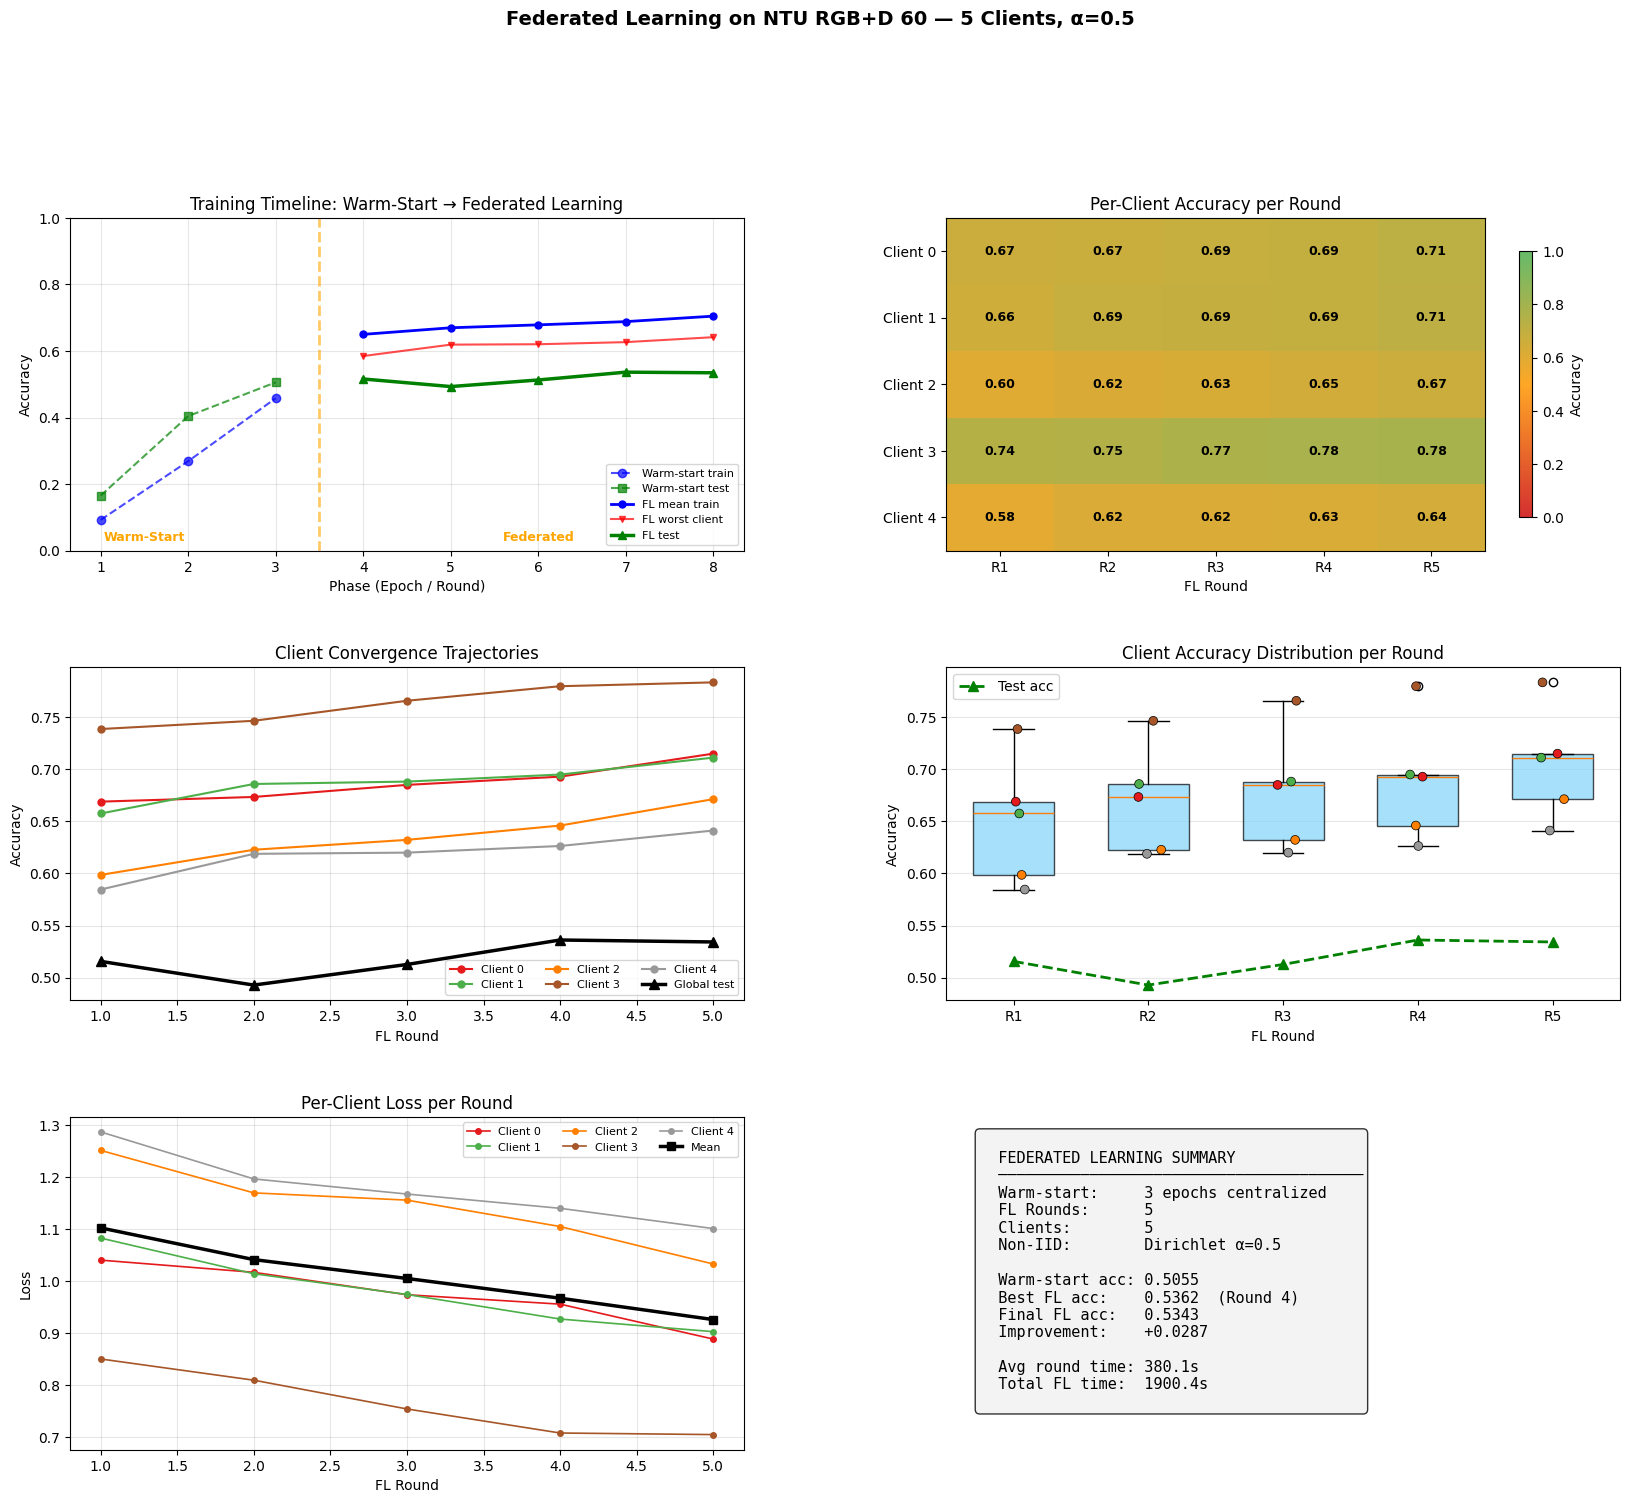

Saved: outputs/fl_visualization.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# ── Panel 1: Full training timeline (warm-start + FL) ──
ax1 = fig.add_subplot(gs[0, 0])

# Warm-start epochs
ws_epochs = [h['epoch'] for h in warmup_history]
ws_train = [h['train_acc'] for h in warmup_history]
ws_test = [h['test_acc'] for h in warmup_history]
ax1.plot(ws_epochs, ws_train, 'b--o', markersize=6, label='Warm-start train', alpha=0.7)
ax1.plot(ws_epochs, ws_test, 'g--s', markersize=6, label='Warm-start test', alpha=0.7)

# FL rounds (offset by warm-start epochs)
offset = len(warmup_history)
fl_rounds = [offset + h['round'] for h in history]
fl_mean = [h['mean_client_acc'] for h in history]
fl_worst = [h['worst_client_acc'] for h in history]
fl_test = [h['test_acc'] for h in history]
ax1.plot(fl_rounds, fl_mean, 'b-o', markersize=5, label='FL mean train', linewidth=2)
ax1.plot(fl_rounds, fl_worst, 'r-v', markersize=5, label='FL worst client', alpha=0.7)
ax1.plot(fl_rounds, fl_test, 'g-^', markersize=6, label='FL test', linewidth=2.5)

# Phase separator
ax1.set_ylim(0, 1.0)
ax1.axvline(x=offset + 0.5, color='orange', linestyle='--', linewidth=2, alpha=0.6)
ax1.text(offset * 0.5, 0.03, 'Warm-Start', ha='center',
         fontsize=9, color='orange', fontweight='bold')
ax1.text(offset + NUM_ROUNDS * 0.5 + 0.5, 0.03, 'Federated',
         ha='center', fontsize=9, color='orange', fontweight='bold')

ax1.set_xlabel('Phase (Epoch / Round)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training Timeline: Warm-Start → Federated Learning')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Panel 2: Client accuracy heatmap ──
ax2 = fig.add_subplot(gs[0, 1])
cam = np.array(client_acc_matrix)  # (rounds, clients)
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#d32f2f', '#ffa726', '#66bb6a'], N=256)
im = ax2.imshow(cam.T, aspect='auto', cmap=cmap_rg, vmin=0, vmax=1, interpolation='nearest')

# Annotate cells
for r in range(cam.shape[0]):
    for c in range(cam.shape[1]):
        val = cam[r, c]
        color = 'white' if val < 0.5 else 'black'
        ax2.text(r, c, f'{val:.2f}', ha='center', va='center', fontsize=9,
                 color=color, fontweight='bold')

ax2.set_xticks(range(len(history)))
ax2.set_xticklabels([f'R{h["round"]}' for h in history])
ax2.set_yticks(range(NUM_CLIENTS))
ax2.set_yticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
ax2.set_xlabel('FL Round')
ax2.set_title('Per-Client Accuracy per Round')
plt.colorbar(im, ax=ax2, label='Accuracy', shrink=0.8)

# ── Panel 3: Client convergence trajectories ──
ax3 = fig.add_subplot(gs[1, 0])
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLIENTS))
for cid in range(NUM_CLIENTS):
    client_acc_trace = [cam[r, cid] for r in range(cam.shape[0])]
    ax3.plot(range(1, len(client_acc_trace) + 1), client_acc_trace,
             '-o', color=colors[cid], label=f'Client {cid}', markersize=5, linewidth=1.5)
ax3.plot(range(1, len(fl_test) + 1), fl_test, 'k-^', label='Global test',
         linewidth=2.5, markersize=7, zorder=10)
ax3.set_xlabel('FL Round')
ax3.set_ylabel('Accuracy')
ax3.set_title('Client Convergence Trajectories')
ax3.legend(fontsize=8, ncol=3)
ax3.grid(True, alpha=0.3)

# ── Panel 4: Per-round accuracy distribution (box plot) ──
ax4 = fig.add_subplot(gs[1, 1])
bp = ax4.boxplot([cam[r] for r in range(cam.shape[0])],
                  labels=[f'R{r+1}' for r in range(cam.shape[0])],
                  patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor('#81d4fa')
    patch.set_alpha(0.7)

# Overlay individual points
for r in range(cam.shape[0]):
    jitter = np.random.uniform(-0.1, 0.1, NUM_CLIENTS)
    ax4.scatter([r + 1 + j for j in jitter], cam[r], c=colors[:NUM_CLIENTS],
                s=40, zorder=5, edgecolors='k', linewidth=0.5)

ax4.plot(range(1, cam.shape[0] + 1), fl_test, 'g--^', label='Test acc', markersize=7, linewidth=2)
ax4.set_xlabel('FL Round')
ax4.set_ylabel('Accuracy')
ax4.set_title('Client Accuracy Distribution per Round')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# ── Panel 5: Loss curves ──
ax5 = fig.add_subplot(gs[2, 0])
for cid in range(NUM_CLIENTS):
    losses = [h['client_losses'][cid] for h in history]
    ax5.plot(range(1, len(losses) + 1), losses, '-o', color=colors[cid],
             label=f'Client {cid}', markersize=4, linewidth=1.2)
mean_losses = [h['mean_client_loss'] for h in history]
ax5.plot(range(1, len(mean_losses) + 1), mean_losses, 'k-s', label='Mean',
         linewidth=2.5, markersize=6, zorder=10)
ax5.set_xlabel('FL Round')
ax5.set_ylabel('Loss')
ax5.set_title('Per-Client Loss per Round')
ax5.legend(fontsize=8, ncol=3)
ax5.grid(True, alpha=0.3)

# ── Panel 6: FL summary stats ──
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')

best_round = max(history, key=lambda h: h['test_acc'])
summary_text = f"""
  FEDERATED LEARNING SUMMARY
  {'─' * 40}
  Warm-start:     {WARMUP_EPOCHS} epochs centralized
  FL Rounds:      {NUM_ROUNDS}
  Clients:        {NUM_CLIENTS}
  Non-IID:        Dirichlet α={ALPHA}

  Warm-start acc: {warmup_history[-1]['test_acc']:.4f}
  Best FL acc:    {best_round['test_acc']:.4f}  (Round {best_round['round']})
  Final FL acc:   {history[-1]['test_acc']:.4f}
  Improvement:    {history[-1]['test_acc'] - warmup_history[-1]['test_acc']:+.4f}

  Avg round time: {np.mean(round_times):.1f}s
  Total FL time:  {sum(round_times):.1f}s
"""
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=11, fontfamily='monospace', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.suptitle(f'Federated Learning on NTU RGB+D 60 — {NUM_CLIENTS} Clients, α={ALPHA}',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('outputs/fl_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fl_visualization.png')

## 9. Export to ONNX

In [14]:
# Export
model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
model.load_state_dict(torch.load('outputs/global_model_ntu60.pt', map_location='cpu'))
model.eval()

dummy = torch.randn(1, 2, 100, 17, 3)
onnx_path = 'outputs/stgcnpp_ntu60_federated.onnx'

torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['skeleton'], output_names=['logits'],
    dynamic_axes={'skeleton': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=12, do_constant_folding=True, dynamo=False,
)
print(f'ONNX exported: {onnx_path}')

# Simplify
try:
    import onnx; from onnxsim import simplify as onnx_simplify
    m = onnx.load(onnx_path)
    simplified, ok = onnx_simplify(m)
    if ok: onnx.save(simplified, onnx_path); print('Simplified ✓')
except: print('Simplify skipped')

# Verify
import onnxruntime as ort
sess = ort.InferenceSession(onnx_path)
inp = sess.get_inputs()[0]
print(f'Input: {inp.name} {inp.shape}')
print(f'Output: {sess.get_outputs()[0].name} {sess.get_outputs()[0].shape}')

ort_out = sess.run(None, {'skeleton': dummy.numpy()})[0]
torch_out = model(dummy).detach().numpy()
diff = abs(ort_out - torch_out).max()
print(f'Max diff: {diff:.2e} {"✓" if diff < 1e-3 else "FAIL"}')

print(f'Model size: {os.path.getsize(onnx_path)/1024**2:.1f} MB')

/tmp/ipykernel_700/115224962.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/tmp/ipykernel_700/3015609789.py:56: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  mt = min(o.size(2) for o in outs)


ONNX exported: outputs/stgcnpp_ntu60_federated.onnx
Simplified ✓
Input: skeleton ['batch', 2, 100, 17, 3]
Output: logits ['batch', 60]
Max diff: 4.58e-05 ✓
Model size: 1.8 MB


## 10. Save Label Map & Retrieve Files

**VS Code users:** Right-click files in Explorer → Download  
**Browser users:** Run the cell to copy to Google Drive

In [15]:
# Write NTU-60 label map
with open('outputs/label_map_ntu60.txt', 'w') as f:
    f.write('\n'.join(NTU60_LABELS) + '\n')
print('Label map: outputs/label_map_ntu60.txt')

# List output files
print('\n── Output files ──')
for fn in ['outputs/stgcnpp_ntu60_federated.onnx',
           'outputs/global_model_ntu60.pt',
           'outputs/fl_history_ntu60.json',
           'outputs/label_map_ntu60.txt']:
    sz = os.path.getsize(fn)
    unit = 'KB' if sz < 1024**2 else 'MB'
    val = sz / 1024 if sz < 1024**2 else sz / 1024**2
    print(f'  {fn:45s} {val:.1f} {unit}')

# Option B: Copy to Google Drive
try:
    import shutil
    from google.colab import drive
    drive.mount('/content/drive')
    dst = '/content/drive/MyDrive/demo1_ntu60_outputs'
    os.makedirs(dst, exist_ok=True)
    for fn in ['outputs/stgcnpp_ntu60_federated.onnx',
               'outputs/global_model_ntu60.pt',
               'outputs/fl_history_ntu60.json',
               'outputs/label_map_ntu60.txt']:
        shutil.copy2(fn, dst)
    print(f'\nCopied to Drive: {dst}')
except Exception as e:
    print(f'\nDrive mount skipped ({e})')
    print('Use VS Code Explorer to download files.')

print(f'''
── Local usage ──
1. Copy stgcnpp_ntu60_federated.onnx → demo/onnx_models/
2. Copy label_map_ntu60.txt → demo1_fed_skeleton/

Then run:
  python demo/demo_onnx.py --device cpu --threads 4 --fast \\
      --recog-model stgcnpp_ntu60_federated.onnx \\
      --label-map demo1_fed_skeleton/label_map_ntu60.txt
''')

Mounted at /content/drive

Copied to Drive: /content/drive/MyDrive/demo1_ntu60_outputs

── Local usage ──
1. Copy stgcnpp_ntu60_federated.onnx → demo/onnx_models/
2. Copy label_map_ntu60.txt → demo1_fed_skeleton/

Then run:
  python demo/demo_onnx.py --device cpu --threads 4 --fast \
      --recog-model stgcnpp_ntu60_federated.onnx \
      --label-map demo1_fed_skeleton/label_map_ntu60.txt



## 11. Quick Inference Test

In [16]:
# Test ONNX on a batch of test samples
import onnxruntime as ort

sess = ort.InferenceSession('outputs/stgcnpp_ntu60_federated.onnx')
test_d = np.load('fed_data/test.npz')
x_t, y_t = test_d['x'].astype(np.float32), test_d['y']

# Batch inference
logits = sess.run(None, {'skeleton': x_t})[0]
preds = logits.argmax(axis=1)
acc = (preds == y_t).mean()

print(f'ONNX test accuracy: {acc:.4f} ({(preds == y_t).sum()}/{len(y_t)})')

# Per-class accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)
for pred, true in zip(preds, y_t):
    class_total[int(true)] += 1
    if pred == true:
        class_correct[int(true)] += 1

class_acc = {cls: class_correct[cls] / class_total[cls]
             for cls in sorted(class_total.keys())}

sorted_classes = sorted(class_acc.items(), key=lambda x: x[1], reverse=True)

print(f'\nTop 10 classes:')
for cls, cacc in sorted_classes[:10]:
    print(f'  {cacc:.1%}  [{cls:2d}] {NTU60_LABELS[cls]}')

print(f'\nBottom 10 classes:')
for cls, cacc in sorted_classes[-10:]:
    print(f'  {cacc:.1%}  [{cls:2d}] {NTU60_LABELS[cls]}')

: 

: 

: 

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(22, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1], wspace=0.3)

# ── Confusion Matrix ──
ax1 = fig.add_subplot(gs[0])
cm = confusion_matrix(y_t, preds, labels=range(NUM_CLASSES))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

im = ax1.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
ax1.set_xlabel('Predicted Class', fontsize=11)
ax1.set_ylabel('True Class', fontsize=11)
ax1.set_title(f'Confusion Matrix — Federated STGCN++ on NTU-60\n'
              f'Overall Accuracy: {acc:.1%}', fontsize=12)
plt.colorbar(im, ax=ax1, label='Recall', shrink=0.8)

# Add tick labels every 5 classes
ax1.set_xticks(range(0, NUM_CLASSES, 5))
ax1.set_yticks(range(0, NUM_CLASSES, 5))
ax1.set_xticklabels(range(0, NUM_CLASSES, 5), fontsize=7)
ax1.set_yticklabels(range(0, NUM_CLASSES, 5), fontsize=7)

# ── Per-class accuracy bar chart ──
ax2 = fig.add_subplot(gs[1])
accs_sorted = sorted(class_acc.items(), key=lambda x: x[1])
cls_ids = [c for c, _ in accs_sorted]
cls_accs = [a for _, a in accs_sorted]
cls_names = [f'[{c}] {NTU60_LABELS[c][:20]}' for c, _ in accs_sorted]

cmap = plt.cm.RdYlGn
bar_colors = [cmap(a) for a in cls_accs]
ax2.barh(range(NUM_CLASSES), cls_accs, color=bar_colors, height=0.8, edgecolor='none')
ax2.set_yticks(range(NUM_CLASSES))
ax2.set_yticklabels(cls_names, fontsize=5.5)
ax2.set_xlabel('Accuracy')
ax2.set_title('Per-Class Accuracy (sorted)')
ax2.axvline(x=acc, color='k', linestyle='--', linewidth=1, alpha=0.5, label=f'Mean={acc:.1%}')
ax2.set_xlim(0, 1.05)
ax2.legend(fontsize=9)

plt.suptitle('Final Model Analysis', fontsize=14, fontweight='bold')
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Most confused pairs
print('\nMost confused action pairs:')
np.fill_diagonal(cm, 0)
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j] >= 5:
            confused_pairs.append((cm[i, j], i, j))
confused_pairs.sort(reverse=True)
for count, true_cls, pred_cls in confused_pairs[:10]:
    print(f'  {NTU60_LABELS[true_cls]:30s} → {NTU60_LABELS[pred_cls]:30s} ({count} times)')

print(f'\nSaved: outputs/confusion_matrix.png')

: 